In [1]:
import pandas as pd

import os
import sys

from dotenv import load_dotenv
import os

# Load .env from the project directory or any other default location
load_dotenv()

In [3]:
import plosbio24_datahelper

species = 'Bacteroides_vulgatus_57955'
datahelper = plosbio24_datahelper.DataHelper_plosbio24(species=species)

In [4]:
datahelper.species, datahelper.genome_len, datahelper.get_close_pairs()

('Bacteroides_vulgatus_57955',
 288298,
 [array(['700037649', 'SRR341696'], dtype=object),
  array(['700033502', '700097688'], dtype=object)])

In [5]:
pairs = datahelper.get_close_pairs()

In [29]:
from importlib import reload
import infer_pipelines
reload(infer_pipelines)

<module 'infer_pipelines' from '/Users/Device6/Documents/Research/bgoodlab/close_pair_hmm/infer_pipelines.py'>

In [30]:
from infer_pipelines import infer_pairs

pair_dat, transfer_dat = infer_pairs(datahelper, clade_cutoff_bin=40)

In [12]:
res = datahelper.get_pair_snp_info(pairs[0])

In [31]:
transfer_dat

,block_start,block_end,snp_vec_start,snp_vec_end,types,genome1,genome2,start_site,end_site,contig
0,6806,7269,68060,72700,0,700037649,SRR341696,1396586,1436661,NC_009614
1,25311,26023,253110,260240,0,700037649,SRR341696,4820703,4916069,NC_009614
0,1967,2047,19670,20480,0,700033502,700097688,357619,363481,NC_009614
1,5173,5219,51730,52200,0,700033502,700097688,849292,865844,NC_009614
2,5494,5548,54940,55490,0,700033502,700097688,1062791,1078569,NC_009614
3,6319,6513,63190,65140,0,700033502,700097688,1199939,1315693,NC_009614
4,6882,7331,68820,73320,0,700033502,700097688,1405427,1446006,NC_009614
5,12261,12646,122610,126470,0,700033502,700097688,2422589,2461893,NC_009614
6,14754,15060,147540,150610,0,700033502,700097688,2894327,2923721,NC_009614
7,18877,19035,188770,190360,0,700033502,700097688,3697220,3733122,NC_009614


In [24]:
res[2][transfer_dat['snp_vec_end'].astype(int).values]

array([1436661, 4916069,  363496,  848014,  919863, 1311120, 1443496,
       2455111, 2914291, 3657134, 3845940, 4766330,  407163,  526161,
        557342,  711125])

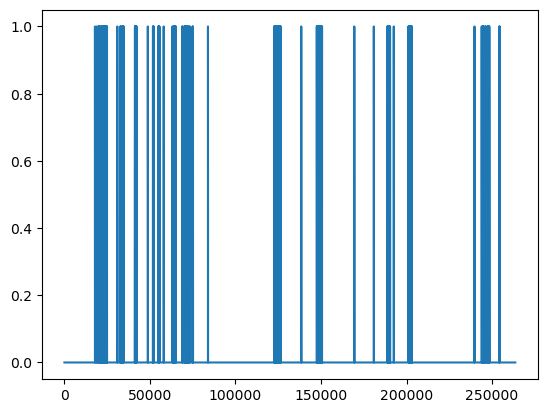

In [10]:
import matplotlib.pyplot as plt

plt.plot(snp_vec)

In [38]:
import numpy as np
# pair = ('700013603', '700013672')
pair = pair2
snv_diffs = snv_helper.compute_pairwise_snvs(pair[0], pair[1])
coverage = snv_helper.compute_pairwise_coverage(pair[0], pair[1])

snp_vec = np.zeros(shape=snv_helper.core_to_snvs.shape[0], dtype=bool)
snp_vec[snv_helper.core_to_snvs] = snv_diffs

snp_vec = snp_vec[snv_helper.core_4D & coverage]

In [48]:
indices = coverage[snv_helper.core_4D & coverage].index

In [50]:
indices

MultiIndex([('NC_009614',     261),
            ('NC_009614',     270),
            ('NC_009614',     282),
            ('NC_009614',     285),
            ('NC_009614',     297),
            ('NC_009614',     306),
            ('NC_009614',     309),
            ('NC_009614',     312),
            ('NC_009614',     315),
            ('NC_009614',     318),
            ...
            ('NC_009614', 5162777),
            ('NC_009614', 5162783),
            ('NC_009614', 5162786),
            ('NC_009614', 5162789),
            ('NC_009614', 5162810),
            ('NC_009614', 5162816),
            ('NC_009614', 5162822),
            ('NC_009614', 5162828),
            ('NC_009614', 5162837),
            ('NC_009614', 5162846)],
           names=['Contig', 'Location'], length=263585)

(0.0, 100000.0)

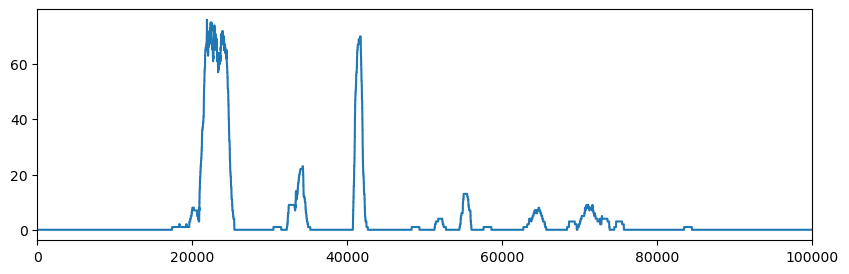

In [51]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 3))
plt.plot(np.convolve(snp_vec, np.ones(1000), mode='same'))
plt.xlim(0, 100000)

In [17]:
snv_diffs

Contig     Location
NC_009614  267         False
           285         False
           352         False
           375         False
           393         False
                       ...  
           5162771     False
           5162780     False
           5162788     False
           5162816     False
           5162846     False
Length: 105479, dtype: bool

In [18]:
coverage

Contig     Location
NC_009614  244          True
           245          True
           246          True
           247          True
           248          True
                       ...  
           5162857     False
           5162858     False
           5162859     False
           5162860     False
           5162861     False
Length: 2057681, dtype: bool

In [34]:
# prepare the plos bio SI table

table_path = 'journal.pbio.3002472.s003.csv'
transfer_table = pd.read_csv(table_path, index_col=0)

transfer_table = transfer_table.loc[transfer_table['Species name']=='Bacteroides_vulgatus_57955']

/var/folders/hg/9rp27v5d51d0948tcdf8mkk80000gq/T/ipykernel_59893/1765176591.py:4: DtypeWarning: Columns (2,6) have mixed types. Specify dtype option on import or set low_memory=False.
  transfer_table = pd.read_csv(table_path, index_col=0)


In [44]:
transfer_table.columns

Index(['Species name', 'Sample 1', 'Sample 2', 'Clonal divergence',
       'Clonal fraction', 'between clade?', 'Shown in Fig3?',
       'Transfer divergence (synonymous)', 'Transfer divergence',
       'Core genome start loc', 'Core genome end loc',
       'Transfer length (# covered sites on core genome)', 'Reference contig',
       'Reference genome start loc', 'Reference genome end loc',
       'Potential duplicate of other events?'],
      dtype='object')

In [36]:
transfer_table.to_csv('LiuGood_pbio24_S3Table_BvOnly.csv')

In [40]:
unique_pairs = transfer_table[['Sample 1', 'Sample 2']].drop_duplicates()
# zip into pairs
pairs = list(zip(unique_pairs['Sample 1'], unique_pairs['Sample 2']))

In [45]:
# Check the dtype of column 2 (third column)
print(transfer_table.iloc[:, 2].dtype)

# Check the dtype of column 6 (seventh column)
print(transfer_table.iloc[:, 6].dtype)

object
bool
